# Cardinality based power index ($\Upsilon$ values) Example:

The purpose of this notebook is to demonstrate the implementation of $\Upsilon$ power-index in the `insert_package_pls` package. Aditionally, we constrast these values against the Shapley index, **insert indices as we go along**.


 The example we consider is due to [Explainability is NOT a Game](https://arxiv.org/abs/2307.07514) paper: $\{x_1,x_2,x_3,x_4\}$ is the feature set, each taking on values from $\{0,1\}$; the binary classifier $\kappa$, classifies each data-pt as follows:

In [49]:
def classifier ( data_pt: list[int] )-> int:
  """ Returns the value of classifier corresponding to the example 
      in explanantion is not a game
      
      Args:
      data_pt (list[int]): A binary list of length 4.
      
      Returns:
      int: The value of classifier.
  """

  if ( data_pt == [0, 0, 0, 1] or
       data_pt == [0, 0, 1, 0] or
       data_pt == [0, 1, 0, 0]
       ) :
       return 1

  else :
    return 0

In [2]:
print(f'The classification of [0,0,1,0] is { classifier ( [0, 0, 1, 0] )}' )
print(f'The classification of [0,0,0,0] is { classifier ( [0, 0, 0, 0] )}' )

The classification of [0,0,1,0] is 1
The classification of [0,0,0,0] is 0


In addition, we require an *initial value function*. Several of them are considered in this notebook, starting with the one in the [above paper](https://arxiv.org/abs/2307.07514).  

## Aggregation based initial value w.r.t. similarity sets

First, we calculate the *similarity set* $\Gamma(\mathbf{v})$ corresponding to a given data-pt $\mathbf{v}$.

In [ ]:
from itertools import product
def similarity_set ( features: list[int], fixed_data_pt: list[int] ) -> list[int]:
  """ Returns the set of data points which agree on the features of
  the fixed_data_pt
  
  Args:
    features (list[int]): A listr of features.
    fixed_data_pt. (list[int]): The reference data point.
  
  Returns:
    list[int]: The list of data points acquired. 
  """
  

  if features :
    prod = product ( [0, 1], repeat=4 )
    data_pts = []

    for x in prod:

      k = 1

      for y in features:

        if ( x [ y ] != fixed_data_pt [ y ] ):
          k = 0

      if ( k == 1 ) :
        data_pts.append ( x )

    return data_pts

  else:

    return []

In [12]:
similarity_set ( features = [ 0 ], fixed_data_pt= [ 0, 0, 0, 0 ] )

[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 1, 0),
 (0, 1, 1, 1)]

And using it, we define the initial strength function:
$$\phi(\mathcal{S},\mathbf{v})=\frac{1}{2^{4-|\mathcal{S}|}}\sum_{\mathbf{x}\in \Gamma}\kappa(\mathbf{x})$$
where $\mathcal{S}$ is a given subset of features.

In [ ]:
import math
def aggregation_sim_set ( players: list[int],
                          input: list[int], 
                          fixed_data_pt = [0,0,0,0] ) -> float:
  """Initial Strength function as defined in the example of Explanation is not a game
  
  Args: 
    players (list[int]): List of players to be passed on.
    input (list[int]): The coalition of features we ask the initial value for.
    fixed_data_pt (list[int]): The point w.r.t. which we find the initial strength.
    
  Returns:
    float: The value w.r.t. to input.
  """

  sim = similarity_set ( input, fixed_data_pt )
  sim_list = [list(x) for x in sim]

  sum = 0

  for x in sim_list:
    sum = sum + classifier (x)


  final_sum = sum / math. pow ( 2, 4 - (len (input)) )


  return final_sum

The function `upsilon_value(player_index ,players, value_function)` calculates the $\Upsilon$ power-index as:
$$\Upsilon_{i}(\phi)=\left[\frac{1}{n\choose i}\sum_{|S|=i}\phi(S)\right]-\left[\frac{1}{n\choose i-1}\sum_{|S|=i-1}\phi(S)\right].$$

To generate the values for the concerned example, we invoke the function with parameters:
  * players = 4
  * value_function = aggregation_sim_set
  * player_index = \{1,2,3,4\}

and represent it graphically.

In [ ]:
from src.powerxai.upsilon_value import upsilon_value
import matplotlib.pyplot as plt
def Upsilon_value_check_aggregation_sim_set ():

  x_1 = upsilon_value (1, [0,1,2,3], aggregation_sim_set)
  x_2 = upsilon_value (2, [0,1,2,3], aggregation_sim_set)
  x_3 = upsilon_value (3, [0,1,2,3], aggregation_sim_set)
  x_4 = upsilon_value (4, [0,1,2,3], aggregation_sim_set)

  print(f'The upsilon-value of 1: {x_1}')
  print(f'The upsilon-value of 2: {x_2}')
  print(f'The upsilon-value of 3: {x_3}')
  print(f'The upsilon-value of 4: {x_4}')

  xaxis = [1, 2, 3, 4]
  yaxis = [x_1, x_2, x_3, x_4]

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

Upsilon_value_check_aggregation_sim_set ()

## Inverse Aggregation based initial value w.r.t. similarity sets

We change our initial value function from Aggregation based initial value w.r.t. similarity sets to the following:

$$\phi(\mathcal{S},\mathbf{v})=\frac{1}{2^{4-|\mathcal{S}|}}\sum_{\mathbf{x}\in \Gamma}(1-\kappa(\mathbf{x}))$$
Intuitively, this captures the instances for which $\kappa$ classifies things as $0$.


In [ ]:
import math
def aggregation_sim_set_inverse ( players: list[int] ,
                                  input: list[int],
                                  fixed_data_pt = [0,0,0,0] ) -> float:
  """Initial Strength function counting the number 0s provided by the classifier,
  The normalisation factor is the same as in the previous case.
  
  Args: 
    players (list[int]): List of players to be passed on.
    input (list[int]): The coalition of features we ask the initial value for.
    fixed_data_pt (list[int]): The point w.r.t. which we find the initial strength.
    
  Returns:
    float: The value w.r.t. to input.
  """

  sim = similarity_set ( input, fixed_data_pt )
  sim_list = [list(x) for x in sim]

  sum = 0

  for x in sim_list:
    sum = sum + (1 - classifier (x))


  final_sum = sum / math. pow ( 2, 4 - (len (input)) )


  return final_sum

Again, we invoke `upsilon_value` the function with parameters:
  * players = 4
  * value_function = aggregation_sim_set_inverse
  * player_index = \{1,2,3,4\}

and represent it graphically.

The upsilon-value of 1: 0.71875
The upsilon-value of 2: -0.09375
The upsilon-value of 3: 0.0
The upsilon-value of 4: 0.375


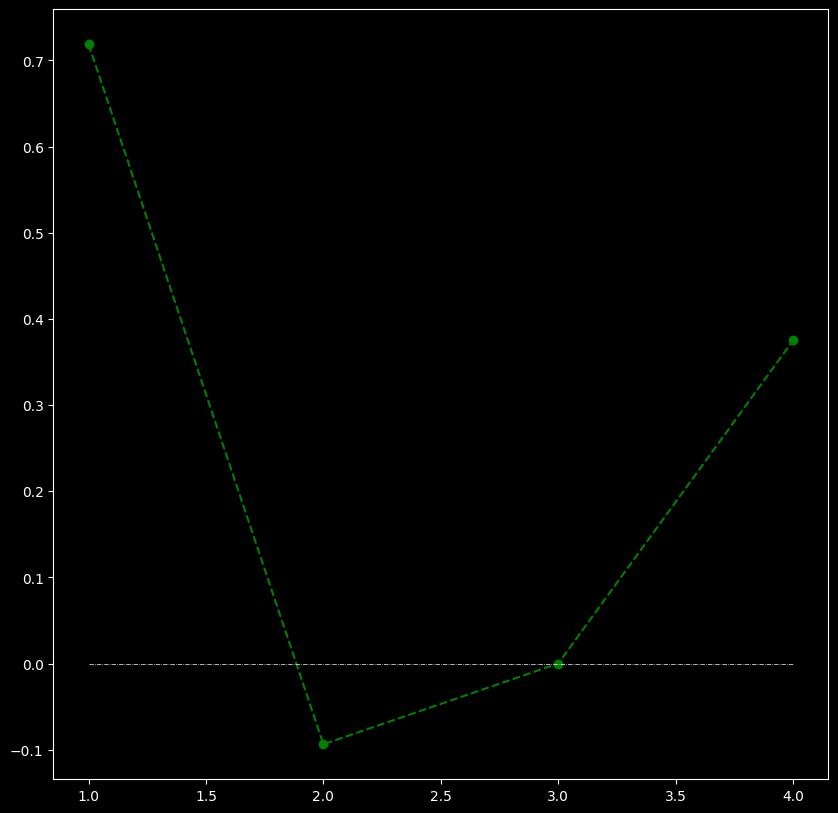

In [22]:
from src.powerxai.upsilon_value import upsilon_value
import matplotlib.pyplot as plt
def Upsilon_value_check_aggregation_sim_set ():
  x_1 = upsilon_value (1, [0,1,2,3], aggregation_sim_set_inverse)
  x_2 = upsilon_value (2, [0,1,2,3], aggregation_sim_set_inverse)
  x_3 = upsilon_value (3, [0,1,2,3], aggregation_sim_set_inverse)
  x_4 = upsilon_value (4, [0,1,2,3], aggregation_sim_set_inverse)

  print(f'The upsilon-value of 1: {x_1}')
  print(f'The upsilon-value of 2: {x_2}')
  print(f'The upsilon-value of 3: {x_3}')
  print(f'The upsilon-value of 4: {x_4}')

  xaxis = [1, 2, 3, 4]
  yaxis = [x_1, x_2, x_3, x_4]

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

Upsilon_value_check_aggregation_sim_set ()

## Aggregation based initial values w.r.t. Sufficieny

A sufficient subset of feature $\cal S$, decides the behavior of $\kappa$ *completely* w.r.t. a data-pt. $\mathbf{v}$. Formally,, any data-pt. $\mathbf{w}$ that agrees with $\mathbf{v}$ on every feature $y\in \cal S$ satisfies $\kappa(\mathbf{v})=\kappa(\mathbf{w})$.

First, we check whether a feature set is sufficient w.r.t. a reference.

In [ ]:
from itertools import product
def partition_of_features (feature_set: list[int],
                           reference =0) -> list[int]:
  """Returns the set of all data points which agree on the feature_set. 
  
  Args: 
    feature_set (list[int]): List of features considered.
    reference (list[int]): A reference data point.
    
  Returns:
    list[int]: A list of data points. 
  """


  full = list (product ( (0,1), repeat=4 ))
  list_for_feature_set =[]
  used = []
  groups = []


  for x in full:

    a = [x[i-1] for i in feature_set]
    list_for_feature_set.append(a)

  list_of_16 = [x for x in range (0,16)]

  while (set(used) != set(list_of_16)):

    list_without_used = [x for x in list_of_16 if x not in used]
    ind = []
    b = list_for_feature_set[list_without_used[0]]

    for i in list_without_used:

      if(list_for_feature_set[i] == b):

        used.append (i)
        ind.append (i)

    groups.append (ind)

  if (reference == 0): return groups

  else:

    k = full.index (reference)

    for x in groups:
      if (k in x): return x



In [ ]:
def suff_check_with_ref (feature_set: list[int],
                          reference: list[int]) -> bool:
  """Checks whether a feature_set is sifficient w.r.t. a reference.
  
  Args: 
    feature_set (list[int]): The considered feature_set.
    reference (list[int]): The data point we check against.
    
  Returns:
    bool: The truth value of the sufficiency check.
  """

  group = partition_of_features (feature_set, reference)

  full = list (product ( (0,1), repeat=4 ))
  c = classifier ( list(reference) )

  for i in group:

    c_1 = classifier ( list( full[i] ) )

    if(c != c_1): return False

  return True

For instance, the whole set $\{x_1,x_2,x_3,x_4\}$ is sufficient w.r.t. to any reference point.

For the example at hand, $x_1$ is sufficient w.r.t. the
data-pt. $1,0,0,1$.

In [24]:
print (f'is [2] sufficient w.r.t. to (1,0,0,0)?{suff_check_with_ref ( [2],  (1,0,0,0) )}')

print (f'is [1] sufficient w.r.t. to (1,0,0,1)?{suff_check_with_ref ( [1],  (1,0,0,1) )}')

is [2] sufficient w.r.t. to (1,0,0,0)?False
is [1] sufficient w.r.t. to (1,0,0,1)?True


Second, given a subset of features $\cal S$ we consider a reference pt. $\mathbf{v}$ and count the number of subsets $\cal T\subseteq S$ that are explanations of $\mathbf{v}$, denoted as $\sigma(\cal S,\mathbf{v} )$ .


In [ ]:
from itertools import product
from src.powerxai.coalitions import coalitions

def suff_check (feature_set: list[int]) -> bool:
  """
    Checks whether a feature set is sufficient. 

    Args:
      feature_set (list[int]): List of features.

    Return:
      bool: Truth value of the sufficiency check.
  """


  groups = partition_of_features (feature_set)

  full = list (product ( (0,1), repeat=4 ))
  for i in groups:

    c_1 = classifier ( list( full[ i[0] ]) )

    for j in i:
      c_2 = classifier ( list( full[j] ) )
      if(c_1 != c_2): return False

  return True


In [ ]:

def aggregation_suff_ref (feature_set: list[int],
                          reference: list[int]) -> float:
  """
    Initial value function defined w.r.t. sufficiency aggregartion. 

    Args:
      feature_set (list[int]): List of features.
      reference (list[int]): The reference data point.

    Return:
      float: Truth value of the sufficiency check.
  """

  fs = len (feature_set)
  possible_sub_feature_sets= coalitions (feature_set)

  sum =0

  for x in possible_sub_feature_sets:

    if (suff_check_with_ref (x, reference)):      sum = sum + 1

  return sum


Lastly, we iterate the procedure for all such data-pt. for a given subset of features. The aggregation based sufficient initial function is defined as:
$$\xi(\cal S) = \frac{ 1 }{ 16 } \sum_{\mathbf{v}}\sigma(\cal{S},\mathbf{v}) $$

In [ ]:
def aggregation_suff (players: list[int],
                       feature_set: list[int]) -> float:
  """Initial value function defined w.r.t. sufficiency aggregartion.
  
    Args:
      players (list[int]): list of players to be passed on.
      feature_set (list[int]): The input of the initial function.

    Returns:
      float: The corresponding initial value.
  """

  full = list (product((0,1), repeat = 4))

  sum = 0

  for x in full:
    sum = sum + aggregation_suff_ref (feature_set, x)

  return sum / 16

Similarly, to check the $\Upsilon$-values w.r.t. the new initial function, invoke `upsilon_value` the function with parameters:
  * players = 4
  * value_function = aggregation_suff
  * player_index = \{1,2,3,4\}.

The data is represented graphically.

The upsilon-value of 1: 0.125
The upsilon-value of 2: 0.5
The upsilon-value of 3: 1.5
The upsilon-value of 4: 4.125


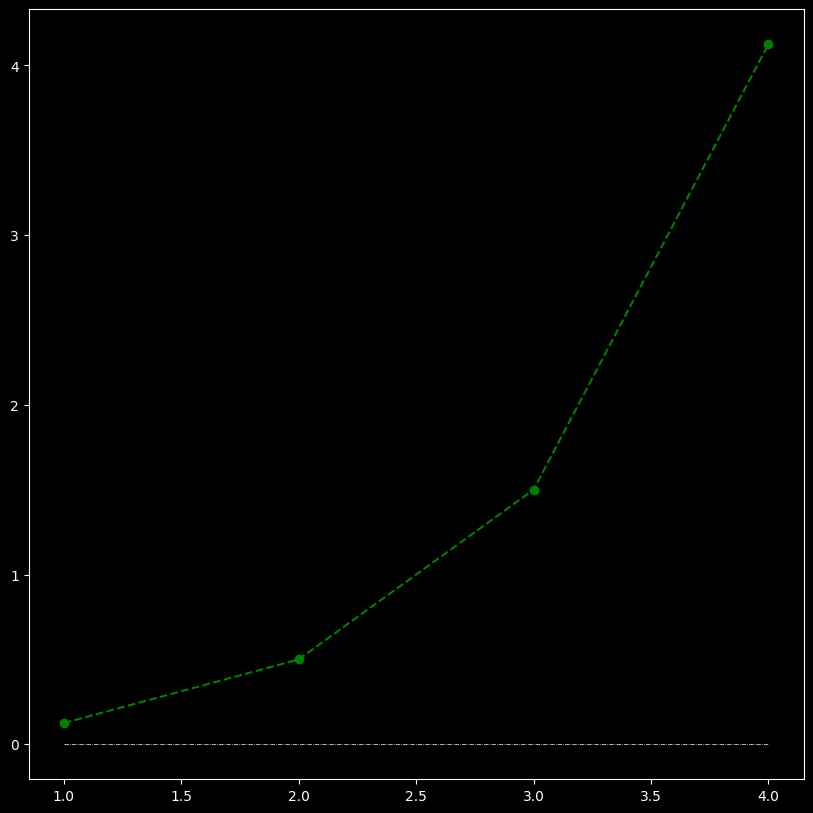

In [31]:
from src.powerxai.upsilon_value import upsilon_value
import matplotlib.pyplot as plt
def Upsilon_value_check_aggregation_suff ():
  x_1 = upsilon_value (1, [0,1,2,3], aggregation_suff)
  x_2 = upsilon_value (2, [0,1,2,3], aggregation_suff)
  x_3 = upsilon_value (3, [0,1,2,3], aggregation_suff)
  x_4 = upsilon_value (4, [0,1,2,3], aggregation_suff)

  print(f'The upsilon-value of 1: {x_1}')
  print(f'The upsilon-value of 2: {x_2}')
  print(f'The upsilon-value of 3: {x_3}')
  print(f'The upsilon-value of 4: {x_4}')

  xaxis = [1, 2, 3, 4]
  yaxis = [x_1, x_2, x_3, x_4]

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

Upsilon_value_check_aggregation_suff ()

Given below, is a graph comparing the $\Upsilon$ values for all the three initial functions.

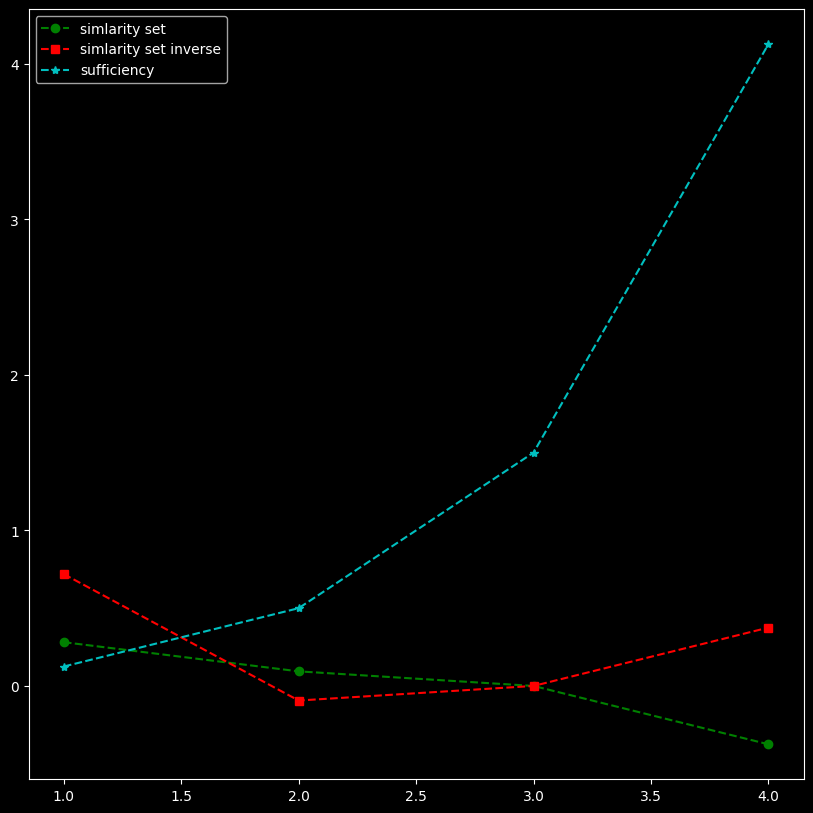

In [34]:
from src.powerxai.upsilon_value import upsilon_value
import matplotlib.pyplot as plt

def comparison_upsilon_values ():

  xaxis =[]

  yaxis_sim_set =[]
  yaxis_sim_set_inverse =[]
  yaxis_sim_suff =[]

  for i in range (1, 5):
    xaxis. append (i)

  for i in range (1, 5):
    yaxis_sim_set. append ( upsilon_value(i, [0,1,2,3], aggregation_sim_set) )

  for i in range (1, 5):
    yaxis_sim_set_inverse. append ( upsilon_value(i, [0,1,2,3], aggregation_sim_set_inverse) )

  for i in range (1, 5):
    yaxis_sim_suff. append ( upsilon_value(i, [0,1,2,3], aggregation_suff) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis_sim_set, 'go', linestyle = 'dashed', label= 'simlarity set')
  plt.plot (xaxis, yaxis_sim_set_inverse, 'rs', linestyle = 'dashed', label= 'simlarity set inverse')
  plt.plot (xaxis, yaxis_sim_suff, 'c*', linestyle = 'dashed', label= 'sufficiency')

  plt.legend()

comparison_upsilon_values ()

## Application to Shapley values

We apply the above introduced initial functions to tthe Shapley power-index. The case of Aggregation based initial values w.r.t. similarity sets has been investigated in Explainability is NOT a game paper.

We re-evaluate the case over here, for the purpose of comparison.  

The shapley-value of 1: 0.21875000000000003
The shapley-value of 2: -0.07291666666666666
The shapley-value of 3: -0.07291666666666666
The shapley-value of 4: -0.07291666666666666


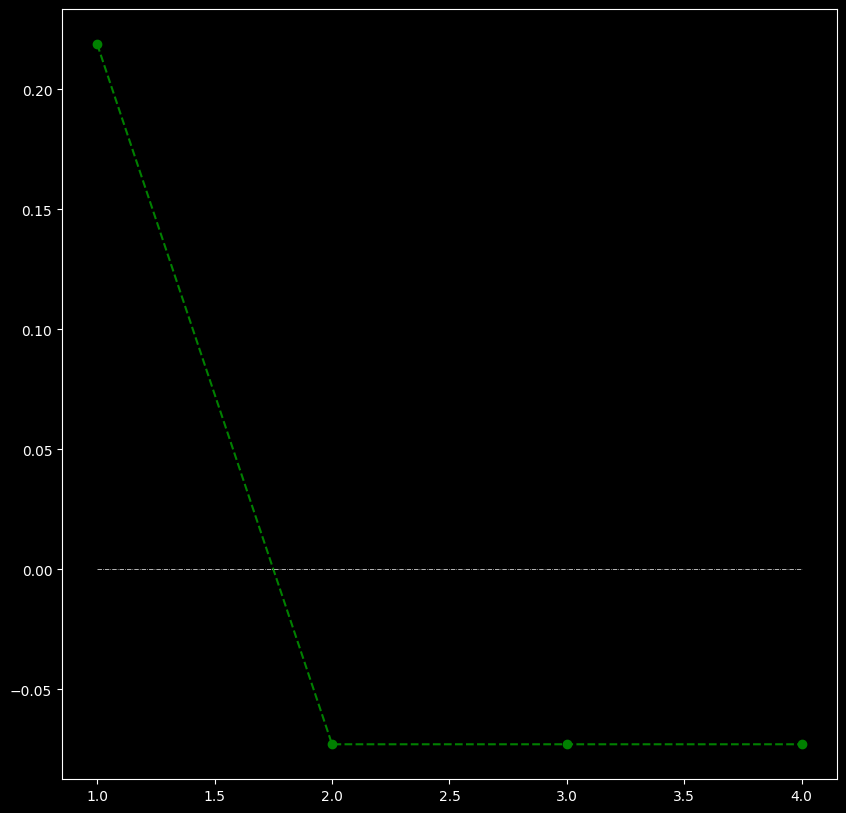

In [39]:
from src.powerxai.shapley_value import shapley_value
import matplotlib.pyplot as plt

def check_shapley_values_aggregation_sim_set ():
  x_14 = shapley_value (0, [0,1,2,3], aggregation_sim_set)
  x_24 = shapley_value (1, [0,1,2,3], aggregation_sim_set)
  x_34 = shapley_value (2, [0,1,2,3], aggregation_sim_set)
  x_44 = shapley_value (3, [0,1,2,3], aggregation_sim_set)

  print(f'The shapley-value of 1: {x_14}')
  print(f'The shapley-value of 2: {x_24}')
  print(f'The shapley-value of 3: {x_34}')
  print(f'The shapley-value of 4: {x_44}')

  xaxis = [1, 2, 3, 4]
  yaxis = [x_14, x_24, x_34, x_44]

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

check_shapley_values_aggregation_sim_set ()


Secondly, we cosnider the shapley values for aggregation based initial functions but for the inverse.

The shapley-value of 1: 0.031250000000000014
The shapley-value of 2: 0.3229166666666667
The shapley-value of 3: 0.3229166666666667
The shapley-value of 4: 0.3229166666666667


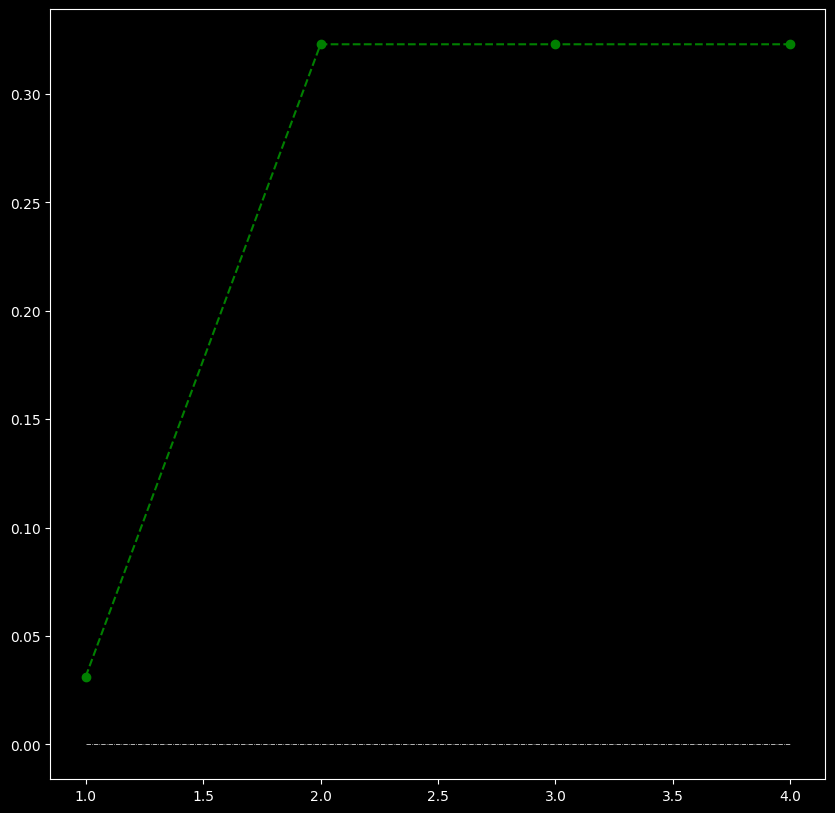

In [35]:
from src.powerxai.shapley_value import shapley_value
import matplotlib.pyplot as plt

def check_shapley_values_aggregation_sim_set_inverse ():
  x_1 = shapley_value (0, [0,1,2,3], aggregation_sim_set_inverse)
  x_2 = shapley_value (1, [0,1,2,3], aggregation_sim_set_inverse)
  x_3 = shapley_value (2, [0,1,2,3], aggregation_sim_set_inverse)
  x_4 = shapley_value (3, [0,1,2,3], aggregation_sim_set_inverse)

  print(f'The shapley-value of 1: {x_1}')
  print(f'The shapley-value of 2: {x_2}')
  print(f'The shapley-value of 3: {x_3}')
  print(f'The shapley-value of 4: {x_4}')

  xaxis = [1, 2, 3, 4]
  yaxis = [x_1, x_2, x_3, x_4]

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

check_shapley_values_aggregation_sim_set_inverse ()

Lastly, we consider the case for sufficiency based initial function.

The shapley-value of 1: 1.375
The shapley-value of 2: 2.125
The shapley-value of 3: 1.375
The shapley-value of 4: 1.375


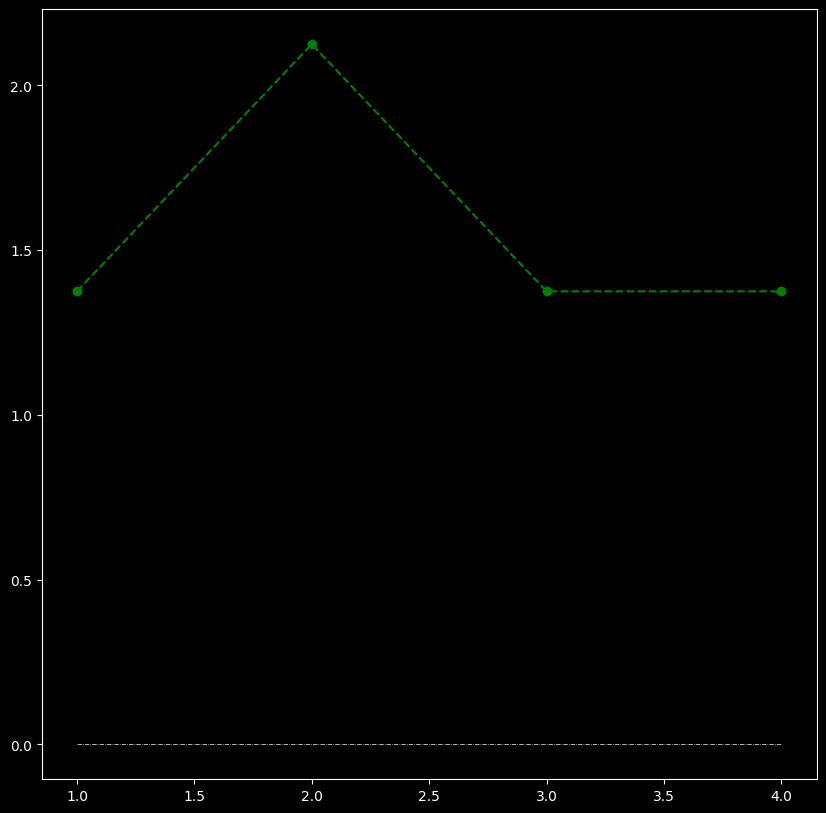

In [37]:
from src.powerxai.shapley_value import shapley_value
import matplotlib.pyplot as plt

def check_shapley_values_aggregation_sim_set ():
  x_1 = shapley_value (0, [0,1,2,3], aggregation_suff)
  x_2 = shapley_value (1, [0,1,2,3], aggregation_suff)
  x_3 = shapley_value (2, [0,1,2,3], aggregation_suff)
  x_4 = shapley_value (3, [0,1,2,3], aggregation_suff)

  print(f'The shapley-value of 1: {x_1}')
  print(f'The shapley-value of 2: {x_2}')
  print(f'The shapley-value of 3: {x_3}')
  print(f'The shapley-value of 4: {x_4}')

  xaxis = [1, 2, 3, 4]
  yaxis = [x_1, x_2, x_3, x_4]

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, yaxis, 'go', linestyle = 'dashed')
  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.show()

check_shapley_values_aggregation_sim_set ()

As in the case for $\Upsilon$ values, we compare all the three initial value problems in the graph below.

In [ ]:
def comparison_shapley_values ():

  xaxis =[]

  yaxis_sim_set =[]
  yaxis_sim_set_inverse =[]
  yaxis_sim_suff =[]

  for i in range (0, 5):
    xaxis. append (i)

  for i in range (0, 5):
    yaxis_sim_set. append ( shapley_value(i, [0,1,2,3], aggregation_sim_set) )

  for i in range (0, 5):
    yaxis_sim_set_inverse. append ( shapley_value(i, [0,1,2,3], aggregation_sim_set) )

  for i in range (0, 5):
    yaxis_sim_suff. append ( shapley_value(i, [0,1,2,3], aggregation_sim_set) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.plot (xaxis, yaxis_sim_set, 'go', linestyle = 'dashed', label= 'simlarity set')
  plt.plot (xaxis, yaxis_sim_set_inverse, 'rs', linestyle = 'dashed', label= 'simlarity set inverse')
  plt.plot (xaxis, yaxis_sim_suff, 'c*', linestyle = 'dashed', label= 'simlarity set sufficiency')

  plt.legend()

comparison_shapley_values()

## Comparsion between Shapley and $\Upsilon$-values

In this section, we compare the shapley and $\Upsilon$ values w.r.t. the above defined initial functions. There are three cases:

1. Aggregation based initial function w.r.t. similarity set

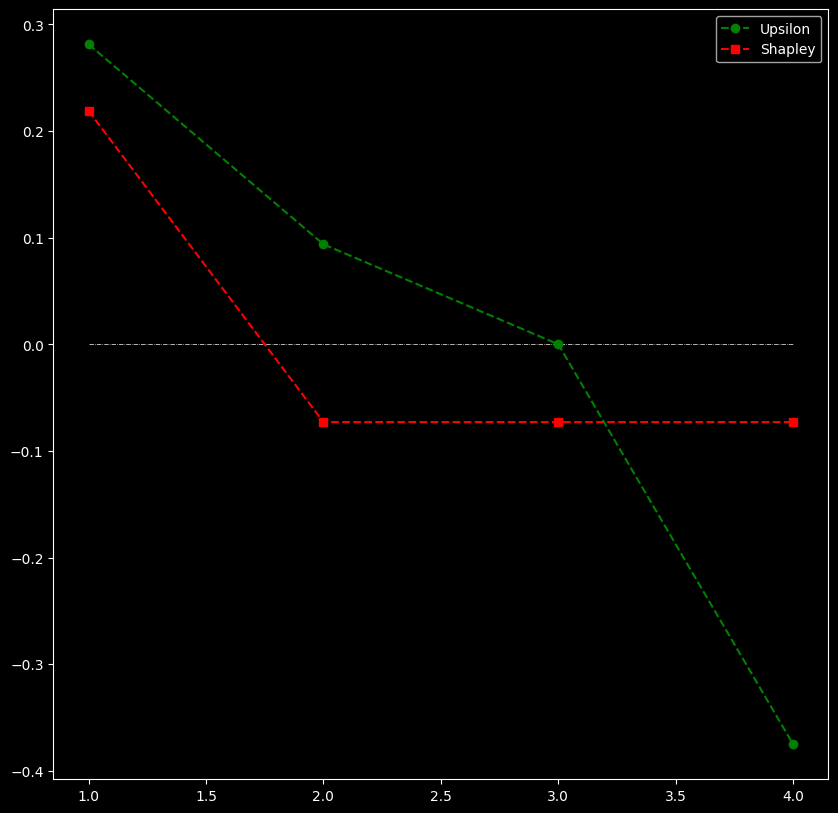

In [44]:
def comparison_between_values_sim_set ():

  xaxis =[]

  yaxis_upsilon =[]
  yaxis_shapley =[]

  for i in range (1, 5):
    xaxis. append (i)

  for i in range (1, 5):
    yaxis_upsilon. append ( upsilon_value(i, [0,1,2,3], aggregation_sim_set) )

  for i in range (1, 5):
    yaxis_shapley. append ( shapley_value(i-1, [0,1,2,3], aggregation_sim_set) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.plot (xaxis, yaxis_upsilon, 'go', linestyle = 'dashed', label= 'Upsilon')
  plt.plot (xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_sim_set()

2. Aggregation based initial function w.r.t. similarity set inverse

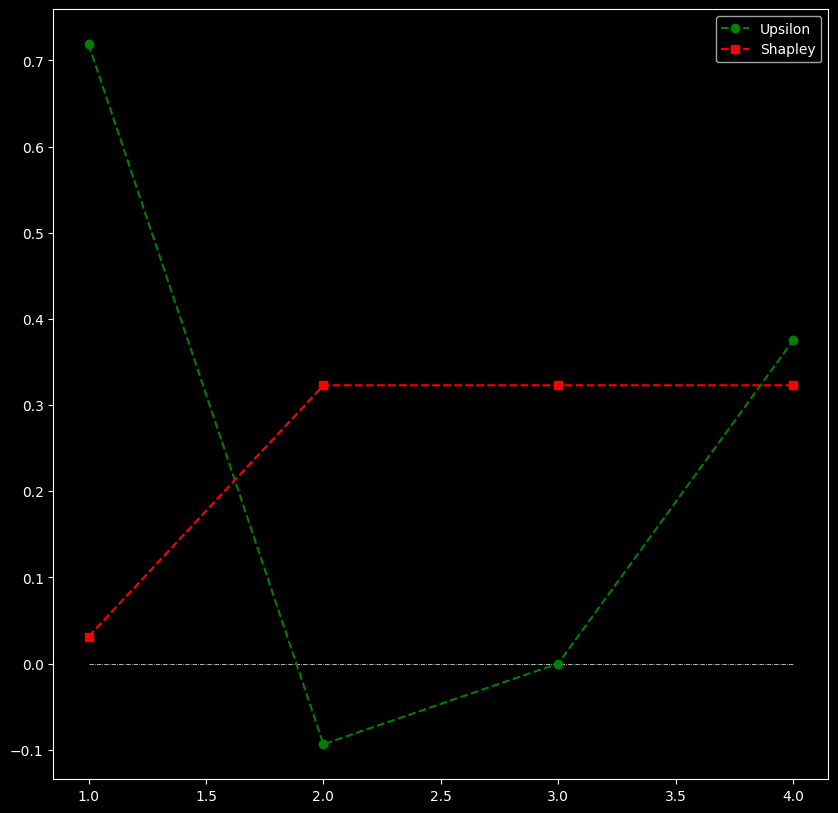

In [47]:
def comparison_between_values_sim_set_inverse ():

  xaxis =[]

  yaxis_upsilon =[]
  yaxis_shapley =[]

  for i in range (1, 5):
    xaxis. append (i)

  for i in range (1, 5):
    yaxis_upsilon. append ( upsilon_value(i, [0,1,2,3], aggregation_sim_set_inverse) )

  for i in range (1, 5):
    yaxis_shapley. append ( shapley_value(i-1, [0,1,2,3], aggregation_sim_set_inverse) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.plot (xaxis, yaxis_upsilon, 'go', linestyle = 'dashed', label= 'Upsilon')
  plt.plot (xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_sim_set_inverse()

3. Aggregation based initial function w.r.t. sufficiency.

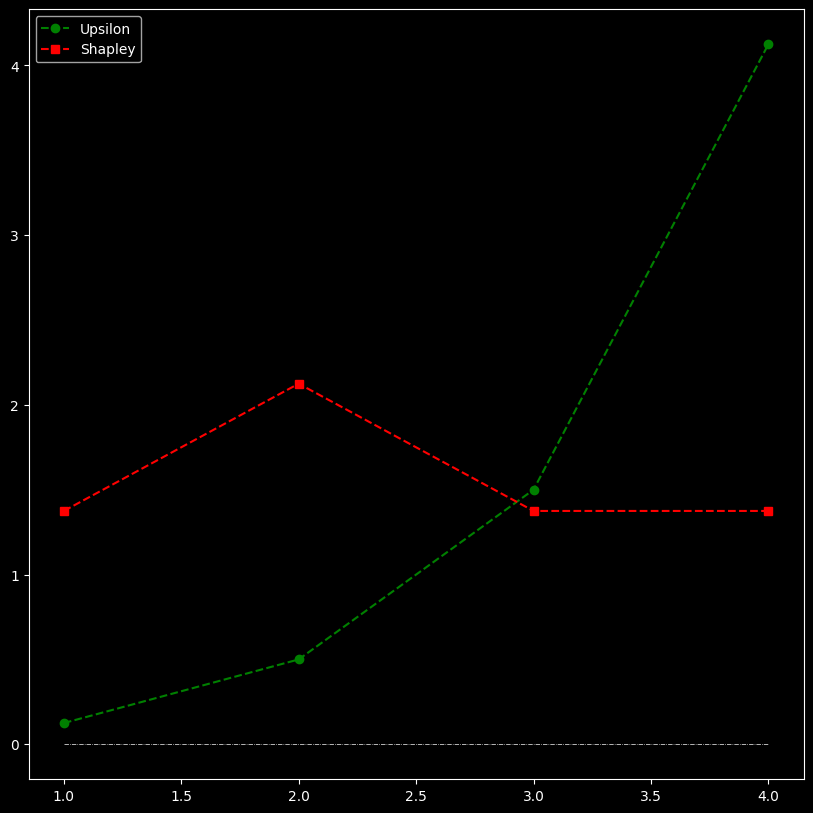

In [48]:
def comparison_between_values_suff ():

  xaxis =[]

  yaxis_upsilon =[]
  yaxis_shapley =[]

  for i in range (1, 5):
    xaxis. append (i)

  for i in range (1, 5):
    yaxis_upsilon. append ( upsilon_value(i, [0,1,2,3], aggregation_suff) )

  for i in range (1, 5):
    yaxis_shapley. append ( shapley_value(i-1, [0,1,2,3], aggregation_suff) )

  plt.style.use ( "dark_background" )
  fig = plt.figure()
  fig.set_figwidth (10)
  fig.set_figheight (10)

  plt.plot (xaxis, [0,0,0,0], 'w-.', linewidth = 0.5)
  plt.plot (xaxis, yaxis_upsilon, 'go', linestyle = 'dashed', label= 'Upsilon')
  plt.plot (xaxis, yaxis_shapley, 'rs', linestyle = 'dashed', label ='Shapley')

  plt.legend()

comparison_between_values_suff()